<a href="https://colab.research.google.com/github/AdenFatima/neurofive-ml-track/blob/main/task8_ensemble_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Task 8: Ensemble Learning (Random Forest vs XGBoost)

In [1]:
# Install xgboost in Colab
!pip install xgboost

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [2]:
# 1. Load and Prepare the Telco Churn Dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/tmp/ipykernel_3585/675847213.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [3]:
# 2. TRAIN THE MODELS
# Baseline: Single Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt_model.predict(X_test))

# Ensemble 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

# Ensemble 2: XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:03:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [4]:
# 3. COMPARE PERFORMANCE
print("--- MODEL COMPARISON ---")
print(f"Single Decision Tree Accuracy: {dt_acc * 100:.2f}%")
print(f"Random Forest Accuracy:        {rf_acc * 100:.2f}%")
print(f"XGBoost Accuracy:              {xgb_acc * 100:.2f}%\n")

--- MODEL COMPARISON ---
Single Decision Tree Accuracy: 80.62%
Random Forest Accuracy:        78.92%
XGBoost Accuracy:              79.42%



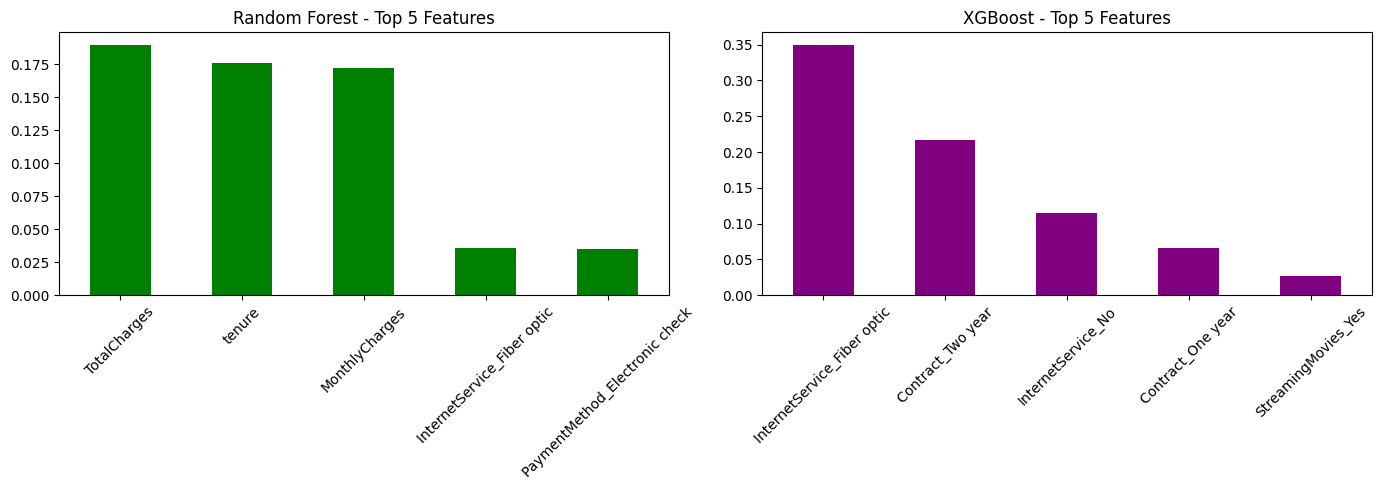

In [5]:
# 4. PLOT FEATURE IMPORTANCES
# Get top 5 features for both ensemble models
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)

# Plotting side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_importances.plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Random Forest - Top 5 Features')
axes[0].tick_params(axis='x', rotation=45)

xgb_importances.plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title('XGBoost - Top 5 Features')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Random Forest vs. XGBoost: How They Combine Models
Random Forest works through a method called **Bagging**. It builds hundreds of independent decision trees at the exact same time, allowing each tree to vote on the final prediction, which helps prevent overfitting.

XGBoost, on the other hand, uses a method called **Boosting**. Instead of building trees independently, it builds them sequentially (one after another). Every new tree in XGBoost specifically analyzes the errors made by the previous trees and attempts to correct them, making it a highly aggressive and optimized learning machine.